In [1]:
!pip install -q ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

dataset = fetch_ucirepo(id=296)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

df = pd.concat([X, y], axis=1)

print(df.shape)
df.head()

/usr/local/lib/python3.13/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


(101766, 48)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
print(df["readmitted"].value_counts(dropna=False))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [4]:
df["readmit_30d"] = (df["readmitted"] == "<30").astype(int)

df["readmit_30d"].value_counts()

,count
readmit_30d,
0,90409
1,11357


In [5]:
df["readmit_30d"].value_counts(normalize=True)

,proportion
readmit_30d,
0,0.888401
1,0.111599


In [6]:
# Missing-value overview
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "question_mark_count": (df.astype(str) == "?").sum()
})

missing_summary = missing_summary[
    (missing_summary["missing_count"] > 0) |
    (missing_summary["question_mark_count"] > 0)
].sort_values(
    ["question_mark_count", "missing_percent"],
    ascending=False
)

missing_summary.head(20)

,missing_count,missing_percent,question_mark_count
weight,98569,96.858479,0
max_glu_serum,96420,94.746772,0
A1Cresult,84748,83.277322,0
medical_specialty,49949,49.082208,0
payer_code,40256,39.557416,0
race,2273,2.233555,0
diag_3,1423,1.398306,0
diag_2,358,0.351787,0
diag_1,21,0.020636,0


## 1. Data Quality Assessment

Before modeling, missing values and placeholder values were examined to identify variables requiring preprocessing.

## 2. Exploratory Data Analysis

The outcome distribution and selected clinical characteristics were explored before model development. Particular attention was given to class imbalance because 30-day readmission is relatively uncommon.

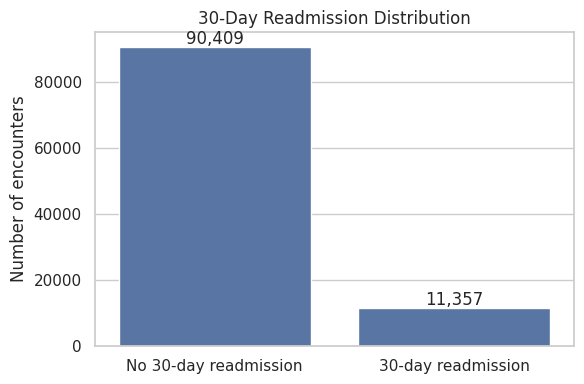

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Target distribution
target_counts = df["readmit_30d"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=["No 30-day readmission", "30-day readmission"],
    y=target_counts.values
)

plt.title("30-Day Readmission Distribution")
plt.ylabel("Number of encounters")
plt.xlabel("")

for i, value in enumerate(target_counts.values):
    ax.text(i, value + 1000, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()

### Observation

Only approximately **11.2%** of encounters resulted in readmission within 30 days, indicating substantial class imbalance. Therefore, model performance should not be evaluated using accuracy alone; recall, F1-score, and ROC-AUC will also be considered.

## 3. Data Preprocessing and Modeling

Variables with extensive missingness were excluded. Remaining numerical and categorical features were processed separately using median imputation, standardization, and one-hot encoding.

A logistic regression model was used as an interpretable baseline for predicting 30-day readmission.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    confusion_matrix
)

# Remove target-related and high-missingness variables
drop_cols = [
    "readmitted",
    "readmit_30d",
    "weight",
    "max_glu_serum",
    "A1Cresult",
    "medical_specialty",
    "payer_code",
    "encounter_id",
    "patient_nbr"
]

X_model = df.drop(
    columns=[c for c in drop_cols if c in df.columns]
)

y_model = df["readmit_30d"]

# Separate numeric and categorical variables
numeric_cols = X_model.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_model.select_dtypes(
    exclude=["int64", "float64"]
).columns

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 81412
Test samples: 20354


## 4. Model Evaluation

Because the outcome is imbalanced, performance was evaluated using multiple metrics rather than accuracy alone.

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.65     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.65      0.71     20354

ROC-AUC: 0.643


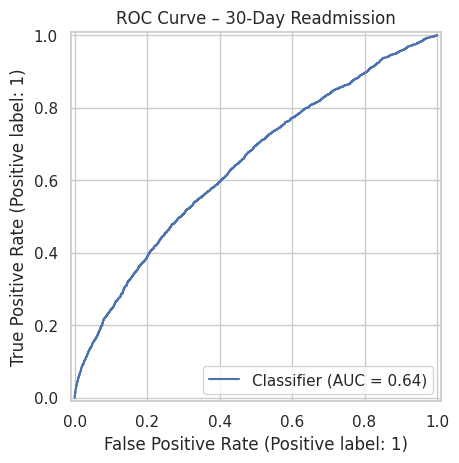

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {auc:.3f}")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve – 30-Day Readmission")
plt.show()

## 5. Model Interpretation

Model errors and feature coefficients were examined to better understand the behavior of the baseline classifier.

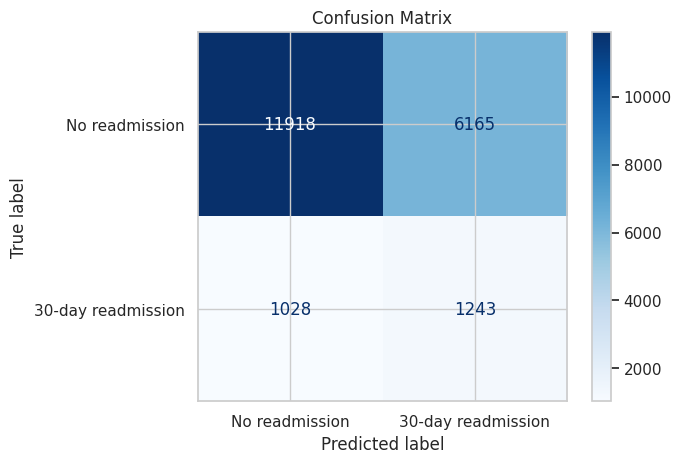

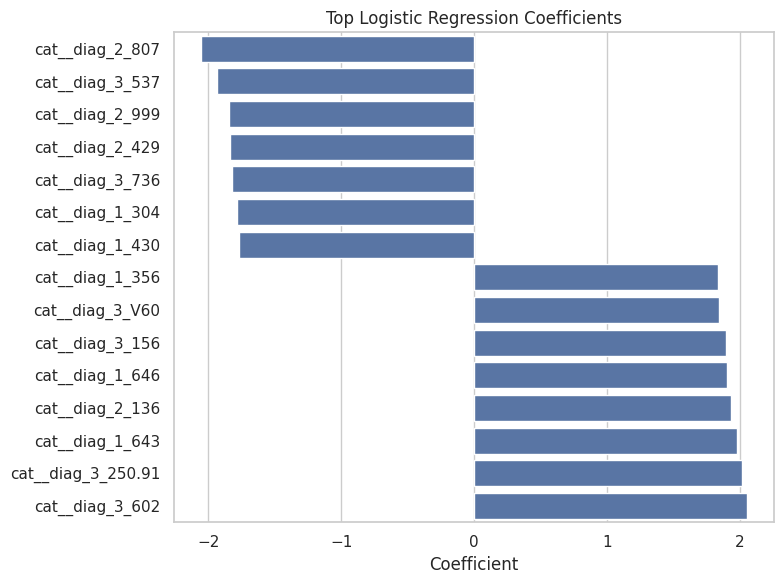

,feature,coefficient,abs_coefficient
1239,cat__diag_2_807,-2.056916,2.056916
1782,cat__diag_3_537,-1.934533,1.934533
1344,cat__diag_2_999,-1.843210,1.843210
977,cat__diag_2_429,-1.837137,1.837137
1931,cat__diag_3_736,-1.819508,1.819508
198,cat__diag_1_304,-1.787714,1.787714
300,cat__diag_1_430,-1.766813,1.766813
239,cat__diag_1_356,1.836978,1.836978
2185,cat__diag_3_V60,1.846500,1.846500
1461,cat__diag_3_156,1.897237,1.897237


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import numpy as np

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No readmission", "30-day readmission"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Extract feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_features = (
    coef_df
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
    .sort_values("coefficient")
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=top_features,
    x="coefficient",
    y="feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

top_features

## 6. Key Findings and Limitations

- Approximately **11.2%** of encounters resulted in readmission within 30 days, creating substantial class imbalance.
- The baseline logistic regression model achieved a **ROC-AUC of 0.643**.
- Using class weighting increased sensitivity to the minority class, with a **recall of 0.55** for 30-day readmission, although precision remained low.
- These results illustrate the trade-off between identifying patients at risk and generating false-positive predictions.
- Model coefficients were examined to identify variables most strongly associated with predicted readmission risk.

### Limitations

This analysis is intended as a portfolio demonstration rather than a clinically deployable prediction model. The dataset is historical, several variables contain substantial missingness, and model performance may not generalize to contemporary clinical populations. Further work could include feature engineering, threshold optimization, external validation, calibration assessment, and comparison with tree-based models.